**Laboratorio #2 - Representaciones básicas de texto**

Juan Diego Letona Aguilar

*20230285*

In [1]:
# Parcialmente reciclado del notebook 1
# la primera parte (imports, carga de paquetes, etc. es practicamente igual a la iteracion anterior)

#principalmente librerias y carga de paquetes necesarios para el proyecto

import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "nltk",
    "matplotlib",
    "wordcloud",
    "spacy",
    "tqdm"
]

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-U", *packages
])

# Modelo pequeño de spaCy para español
subprocess.check_call([
    sys.executable, "-m", "spacy", "download", "es_core_news_sm"
])

0

In [2]:
from pathlib import Path
from collections import Counter
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

#voy a usar spacy porque el corpus es en español y spacy tiene un modelo para español
#otros modelos suelen funcionar mejor para el idioma ingles
#depende del caso de uso

import spacy
from tqdm.auto import tqdm
from wordcloud import WordCloud

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

#recursos de NLTK
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Librerías cargadas correctamente.")

c:\Users\juanl\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


In [3]:
import pandas as pd

df = pd.read_csv("df_total.csv")
#leemos el archivo csv y lo guardamos en un DataFrame de pandas

print("Dimensiones del DataFrame:", df.shape)
display(df.head())

Dimensiones del DataFrame: (1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...,Otra


In [4]:
#configuracion y descripcion de columnas

URL_COL = "url"
TEXT_COL = "news"
CATEGORY_COL = "Type"

descripcion = {
    URL_COL: "enlace original de la noticia",
    TEXT_COL: "contenido textual de la noticia",
    CATEGORY_COL: "categoria asignada a la noticia"
}

columnas = pd.DataFrame({
    "columna": descripcion.keys(),
    "tipo_de_dato": [str(df[col].dtype) for col in descripcion],
    "informacion": descripcion.values()
})

display(
    columnas.style
    .hide(axis="index")
    .set_caption("Columnas del corpus")
)

columna,tipo_de_dato,informacion
url,str,enlace original de la noticia
news,str,contenido textual de la noticia
Type,str,categoria asignada a la noticia


In [5]:
#preparamos el corpus para el procesamiento

corpus = df[[URL_COL, TEXT_COL, CATEGORY_COL]].copy()

corpus[TEXT_COL] = corpus[TEXT_COL].fillna("").astype(str)
corpus = corpus[corpus[TEXT_COL].str.strip().ne("")]
corpus = corpus.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)

stopwords_es = set(stopwords.words("spanish"))

#basicamente quitamos la puntuacion de los tokens, para que no afecte el conteo de palabras y tipos de palabras

def quitar_puntuacion(token):
    return "".join(
        caracter for caracter in token
        if not unicodedata.category(caracter).startswith("P")
    ).strip()

def contar_tokens_tipos(columna):
    tokens = [token for documento in columna for token in documento]
    return len(tokens), len(set(tokens))

print("Documentos que serán procesados:", len(corpus))

Documentos que serán procesados: 1137


In [6]:
#tokenizacion

tqdm.pandas(desc="Tokenizando")

corpus["tokens_tokenizados"] = corpus[TEXT_COL].progress_apply(
    lambda texto: word_tokenize(texto, language="spanish")
)

#minusculas

corpus["tokens_minusculas"] = corpus["tokens_tokenizados"].apply(
    lambda tokens: [token.lower() for token in tokens]
)

#eliminacion de puntuacion

corpus["tokens_sin_puntuacion"] = corpus["tokens_minusculas"].apply(
    lambda tokens: [
        limpio for token in tokens
        if (limpio := quitar_puntuacion(token))
    ]
)

#eliminacion de stopwords

corpus["tokens_sin_stopwords"] = corpus["tokens_sin_puntuacion"].apply(
    lambda tokens: [token for token in tokens if token not in stopwords_es]
)

Tokenizando: 100%|██████████| 1137/1137 [00:04<00:00, 252.95it/s]


In [7]:
#lematizacion
nlp = spacy.load(
    "es_core_news_sm",
    disable=["parser", "ner"]
)
textos = corpus["tokens_sin_stopwords"].apply(" ".join)
corpus["tokens_lematizados"] = [
    [
        token.lemma_.lower()
        for token in documento
        if token.lemma_.strip()
    ]
    for documento in tqdm(
        nlp.pipe(textos, batch_size=64),
        total=len(textos),
        desc="Lematizando"
    )
]
#tokens y tipos despues de cada etapa
etapas = {
    "Tokenización": "tokens_tokenizados",
    "Minúsculas": "tokens_minusculas",
    "Sin puntuación": "tokens_sin_puntuacion",
    "Sin stopwords": "tokens_sin_stopwords",
    "Lematización": "tokens_lematizados"
}
resultados = []
for etapa, columna in etapas.items():
    tokens, tipos = contar_tokens_tipos(corpus[columna])

    resultados.append({
        "etapa": etapa,
        "tokens": tokens,
        "tipos": tipos
    })

resumen_etapas = pd.DataFrame(resultados)
resumen_etapas["cambio_tokens"] = (
    resumen_etapas["tokens"].diff()
)
resumen_etapas["reduccion_vocabulario_%"] = (
    resumen_etapas["tipos"]
    .pct_change()
    .mul(-100)
    .round(2)
)
display(
    resumen_etapas.style
    .hide(axis="index")
    .set_caption("Tokens y tipos después de cada etapa")
)
#cambio producido durante la lematizacion
tokens_antes_lematizar = resumen_etapas.loc[
    resumen_etapas["etapa"] == "Sin stopwords",
    "tokens"
].iloc[0]

tokens_despues_lematizar = resumen_etapas.loc[
    resumen_etapas["etapa"] == "Lematización",
    "tokens"
].iloc[0]
diferencia_lematizacion = (
    tokens_despues_lematizar - tokens_antes_lematizar
)
if diferencia_lematizacion > 0:
    print(
        f"La lematización produjo un aumento de "
        f"{diferencia_lematizacion:,} tokens."
    )
elif diferencia_lematizacion < 0:
    print(
        f"La lematización produjo una reducción de "
        f"{abs(diferencia_lematizacion):,} tokens."
    )
else:
    print("La lematización no cambió la cantidad de tokens.")

Lematizando: 100%|██████████| 1137/1137 [00:41<00:00, 27.30it/s]


etapa,tokens,tipos,cambio_tokens,reduccion_vocabulario_%
Tokenización,631740,38941,nan,nan
Minúsculas,631740,36093,0.000000,7.310000
Sin puntuación,598600,35460,-33140.000000,1.750000
Sin stopwords,319034,35248,-279566.000000,0.600000
Lematización,319318,28292,284.000000,19.730000


La lematización produjo un aumento de 284 tokens.


In [8]:
#texto normalizado por documento

corpus["texto_normalizado"] = corpus["tokens_lematizados"].apply(
    lambda tokens: " ".join(tokens)
)

display(
    corpus[
        [
            TEXT_COL,
            CATEGORY_COL,
            "tokens_lematizados",
            "texto_normalizado"
        ]
    ].head()
)

,news,Type,tokens_lematizados,texto_normalizado
0,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra,"[foro, banca, articulador, empresarial, desarrollo, sostenible, director, sostenibilidad, cliente, global, bbva, colombia, andrés, garcía, asegura...",foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante en...
1,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones,"[regulador, valor, chino, decir, domingo, buscar, cooperación, estrecho, par, estadounidense, apoyar, salida, bolso, extranjero, luego, supervisor...",regulador valor chino decir domingo buscar cooperación estrecho par estadounidense apoyar salida bolso extranjero luego supervisor estadounidense ...
2,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas,"[industria, históricamente, masculino, aviación, vivo, presentar, avión, rosado, a320neo, apostar, equidad, género, lucha, cáncer, mama, inclusión...",industria históricamente masculino aviación vivo presentar avión rosado a320neo apostar equidad género lucha cáncer mama inclusión diversidaddesde...
3,Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, decimoquinto, tasa, positivo, consecutivo, inflación, publicado, ine, mantenido, igual, respecto, avance...",dato marzo ipc interanual encadenar decimoquinto tasa positivo consecutivo inflación publicado ine mantenido igual respecto avance 30 marzo situar...
4,Ayer en Cartagena se dio inicio a la versión número 56 de la Convención Bancaria. Este será el primer encuentro de los banqueros del país con el p...,Otra,"[ayer, cartagena, dar, inicio, versión, número, 56, convención, bancario, primero, encuentro, banquero, país, presidente, gustavo, petro, sesión, ...",ayer cartagena dar inicio versión número 56 convención bancario primero encuentro banquero país presidente gustavo petro sesión clausura próximo v...


**Scikit-learn**

**Bolsa de palabras (Bag of Words)**

In [9]:
#instalamos scikit-learn para poder utilizar CountVectorizer

import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "scikit-learn"
])

print("scikit-learn instalado correctamente.")

#bolsa de palabras (Bag of Words)

from sklearn.feature_extraction.text import CountVectorizer

scikit-learn instalado correctamente.


In [10]:
#creamos la representacion de bolsa de palabras utilizando el texto ya normalizado

vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

matriz_bow = vectorizador_bow.fit_transform(
    corpus["texto_normalizado"]
)

print("Forma de la matriz BoW:", matriz_bow.shape)
print("Numero de documentos:", matriz_bow.shape[0])
print("Tamaño del vocabulario:", matriz_bow.shape[1])

Forma de la matriz BoW: (1137, 27799)
Numero de documentos: 1137
Tamaño del vocabulario: 27799


In [11]:
#obtenemos el vocabulario generado por CountVectorizer

vocabulario_bow = vectorizador_bow.get_feature_names_out()

print("Cantidad de palabras en el vocabulario:", len(vocabulario_bow))
print("Primeras 20 palabras del vocabulario:")
print(vocabulario_bow[:20])

Cantidad de palabras en el vocabulario: 27799
Primeras 20 palabras del vocabulario:
['$' '+' '+17' '0' '00' '000' '0001' '001' '002' '003' '003en' '003la'
 '003por' '003se' '004' '005' '0052020smv' '005seguimos' '006' '006la']


In [12]:
#vemos la representacion BoW del primer documento

primer_documento_bow = matriz_bow[0].toarray()[0]

palabras_documento = [
    (vocabulario_bow[i], frecuencia)
    for i, frecuencia in enumerate(primer_documento_bow)
    if frecuencia > 0
]

print("Texto normalizado:")
print(corpus["texto_normalizado"].iloc[0])

print("\nPalabras y frecuencias en BoW:")
print(palabras_documento[:20])

Texto normalizado:
foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante entender sostenibilidad poder asociar mayor costo creer tener concepto negocio sostenible poder tener mayor impacto imaginamospar garcía reto importante cambiar prioridad compitar necesariamente caso deber tratar mantener prioridad cuanto ambición negocio sostenible reto enorme coyunturo sostenibilidad abrir oportunidad mejor fuente financiamiento agregóel directivo argumentar encontrar juego acá tema rentabilidad negocio particular tema viabilidad mundo negocio mundo físico general conocer además riesgo físico transición asociados cambio climático inclusión social desarrollo real ahíesto dejar ser aspecto paralelo responsabilidad social corporativo ahora adn estrategia mismo negocio solo manera lograr impulsar proyecto específico ir incluir dentro aspiración concluir

Palabras y frecuencias en BoW:
[('abrir', np.int64(1)), (

*La representacion bag of words convierte un texto en una serie de numeros que indican cuantas veces aparece una palabra, 
como vimos en clase. Para hacerlo, se crea un vocabulario con todas las palabras diferentes y despues contamos la frecuencia 
en cada documento. Al usar este metodo, se pierde el orden en que aparecen las palabras por lo que tambien se pierte parte de la 
gramatica y el contexto. Esto implica que dos oraciones formadas por las mismas palabras, pero en distinto orden, pueden terminar 
con una representacion parecida, incluso si su significado es muy distinto. Tambien se ganan varias cosas, como una representacion 
numerica simple que facilita el procesamiento de los textos por los algoritmos de aprendizaje automatico. Tambien permite comparar 
documetnos de acuerdo con las palabras que contienen y la cantidad de veces que aparecen.*

**Vectores de conteo y dispersión**


In [13]:
#calculamos la dispersion de la matriz BoW

total_celdas = matriz_bow.shape[0] * matriz_bow.shape[1]
celdas_no_cero = matriz_bow.nnz
celdas_cero = total_celdas - celdas_no_cero

dispersion_bow = (celdas_cero / total_celdas) * 100

print("Forma de la matriz:", matriz_bow.shape)
print("Total de celdas:", total_celdas)
print("Celdas diferentes de cero:", celdas_no_cero)
print("Celdas con valor cero:", celdas_cero)
print(f"Dispersión de la matriz: {dispersion_bow:.2f}%")

Forma de la matriz: (1137, 27799)
Total de celdas: 31607463
Celdas diferentes de cero: 220137
Celdas con valor cero: 31387326
Dispersión de la matriz: 99.30%


In [14]:
#calculamos la dispersion para diferentes tamaños de vocabulario

tamanos_vocabulario = [100, 500, 1000, 5000]

resultados_dispersion = []

for tamano in tamanos_vocabulario:

    vectorizador = CountVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        max_features=tamano
    )

    matriz = vectorizador.fit_transform(
        corpus["texto_normalizado"]
    )

    total_celdas = matriz.shape[0] * matriz.shape[1]
    celdas_no_cero = matriz.nnz
    celdas_cero = total_celdas - celdas_no_cero

    dispersion = (celdas_cero / total_celdas) * 100

    resultados_dispersion.append({
        "vocabulario": matriz.shape[1],
        "documentos": matriz.shape[0],
        "celdas_no_cero": celdas_no_cero,
        "dispersion_%": dispersion
    })

dispersion_df = pd.DataFrame(resultados_dispersion)

display(dispersion_df)

,vocabulario,documentos,celdas_no_cero,dispersion_%
0,100,1137,34248,69.878628
1,500,1137,91700,83.869833
2,1000,1137,124480,89.051891
3,5000,1137,185883,96.730290


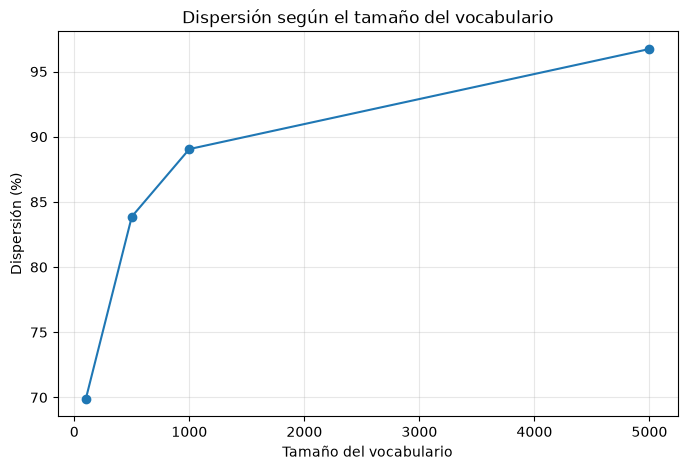

In [15]:
#graficamos como cambia la dispersion al aumentar el vocabulario

plt.figure(figsize=(8, 5))

plt.plot(
    dispersion_df["vocabulario"],
    dispersion_df["dispersion_%"],
    marker="o"
)

plt.title("Dispersión según el tamaño del vocabulario")
plt.xlabel("Tamaño del vocabulario")
plt.ylabel("Dispersión (%)")
plt.grid(alpha=0.3)

plt.show()

In [16]:
#verificamos el tipo de estructura utilizada para almacenar la matriz

print("Tipo de matriz:")
print(type(matriz_bow))

print("\nForma:", matriz_bow.shape)
print("Valores almacenados:", matriz_bow.nnz)

Tipo de matriz:
<class 'scipy.sparse._csr.csr_matrix'>

Forma: (1137, 27799)
Valores almacenados: 220137


*Una matriz dispera (o sparse matrix) es una matriz en la que la mayoria de los valores son cero. Esto ocurre mucho en bag of words poque cada documento solo usa una parte de todas las palabras que existen en el vocabulario. Por esto mismo, las representaciones de texto suelen tener muchas columnas pero pocos valores que son distintos de cero. Entonces, en vez de usar una matriz densa que almacena todos los valores incluyendo ceros, se usan estructuras como el CSR (compressed sparse row). Este formato guarda principamlente los valores distintos de cero y la informacion necesaria para indicar su posicion. De esta manera se reduce mucho el uso de memoria y se pueden realizar de forma eficiente operaciones matematicas, productos con vectores y accesos por filas. Herramientas como countvectorizer de scikit learn producen directamente una representacion dispersa de los conteos de palabras y por lo tanto evitan almacenar muchos ceros que son innecesarios.*

**N-gramas**

In [17]:
#representacion utilizando unigramas

vectorizador_unigramas = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 1)
)

matriz_unigramas = vectorizador_unigramas.fit_transform(
    corpus["texto_normalizado"]
)

vocabulario_unigramas = vectorizador_unigramas.get_feature_names_out()

print("Forma de la matriz de unigramas:", matriz_unigramas.shape)
print("Tamaño del vocabulario de unigramas:", len(vocabulario_unigramas))

Forma de la matriz de unigramas: (1137, 27799)
Tamaño del vocabulario de unigramas: 27799


In [18]:
#representacion utilizando bigramas

vectorizador_bigramas = CountVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False,
    ngram_range=(2, 2)
)

matriz_bigramas = vectorizador_bigramas.fit_transform(
    corpus["texto_normalizado"]
)

vocabulario_bigramas = vectorizador_bigramas.get_feature_names_out()

print("Forma de la matriz de bigramas:", matriz_bigramas.shape)
print("Tamaño del vocabulario de bigramas:", len(vocabulario_bigramas))

Forma de la matriz de bigramas: (1137, 227919)
Tamaño del vocabulario de bigramas: 227919


In [19]:
#comparamos el tamaño de los vocabularios

comparacion_ngramas = pd.DataFrame({
    "representacion": [
        "Unigramas",
        "Bigramas"
    ],
    "tamaño_vocabulario": [
        len(vocabulario_unigramas),
        len(vocabulario_bigramas)
    ]
})

display(comparacion_ngramas)

,representacion,tamaño_vocabulario
0,Unigramas,27799
1,Bigramas,227919


In [20]:
#calculamos la frecuencia total de cada bigrama en el corpus

frecuencias_bigramas = np.asarray(
    matriz_bigramas.sum(axis=0)
).ravel()

indices_ordenados = frecuencias_bigramas.argsort()[::-1]

top_15_bigramas = pd.DataFrame({
    "bigrama": vocabulario_bigramas[
        indices_ordenados[:15]
    ],
    "frecuencia": frecuencias_bigramas[
        indices_ordenados[:15]
    ]
})

display(
    top_15_bigramas.style
    .hide(axis="index")
    .set_caption("15 bigramas más frecuentes del corpus")
)

bigrama,frecuencia
` `,216
banco central,210
poder ser,201
bbva research,186
tasa interés,183
cada vez,183
entidad financiero,160
cambio climático,150
punto básico,139
bbva méxico,132


In [21]:
#calculamos cuanto aumenta el vocabulario al utilizar bigramas

aumento_vocabulario = (
    len(vocabulario_bigramas)
    - len(vocabulario_unigramas)
)

aumento_porcentual = (
    aumento_vocabulario
    / len(vocabulario_unigramas)
) * 100

print(
    "Vocabulario de unigramas:",
    len(vocabulario_unigramas)
)

print(
    "Vocabulario de bigramas:",
    len(vocabulario_bigramas)
)

print(
    "Aumento en cantidad de términos:",
    aumento_vocabulario
)

print(
    f"Aumento porcentual: {aumento_porcentual:.2f}%"
)

Vocabulario de unigramas: 27799
Vocabulario de bigramas: 227919
Aumento en cantidad de términos: 200120
Aumento porcentual: 719.88%


Los bigramas y trigramas tienen la ventaja de conservar parte del orden y la relacion entre palabras consecutivas, por lo que pueden capturar expresiones y contexto que los unigramas pierden. El costo es un aumento considerable del vocabulario: en este corpus se pasó de *27,799 unigramas a 227,919 bigramas*, un aumento de aproximadamente *719.88%*. Los trigramas aumentarían todavia mas esta dimensionalidad, requiriendo mayor almacenamiento y procesamiento.


TF-IDF

In [22]:
corpus["texto_normalizado"]

0       foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante en...
1       regulador valor chino decir domingo buscar cooperación estrecho par estadounidense apoyar salida bolso extranjero luego supervisor estadounidense ...
2       industria históricamente masculino aviación vivo presentar avión rosado a320neo apostar equidad género lucha cáncer mama inclusión diversidaddesde...
3       dato marzo ipc interanual encadenar decimoquinto tasa positivo consecutivo inflación publicado ine mantenido igual respecto avance 30 marzo situar...
4       ayer cartagena dar inicio versión número 56 convención bancario primero encuentro banquero país presidente gustavo petro sesión clausura próximo v...
                                                                                ...                                                                          
1132    vida todo empresa emergente llegar momento i

In [23]:
#representacion TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

matriz_tfidf = vectorizador_tfidf.fit_transform(
    corpus["texto_normalizado"]
)

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()

print("Forma de la matriz TF-IDF:", matriz_tfidf.shape)
print("Tamaño del vocabulario:", len(vocabulario_tfidf))

Forma de la matriz TF-IDF: (1137, 27799)
Tamaño del vocabulario: 27799


In [24]:
#seleccionamos 3 documentos de categorias distintas

categorias_seleccionadas = (
    corpus[CATEGORY_COL]
    .dropna()
    .drop_duplicates()
    .head(3)
    .tolist()
)

indices_documentos = [
    corpus[
        corpus[CATEGORY_COL] == categoria
    ].index[0]
    for categoria in categorias_seleccionadas
]

documentos_seleccionados = corpus.loc[
    indices_documentos,
    [
        TEXT_COL,
        CATEGORY_COL,
        "texto_normalizado"
    ]
]

display(documentos_seleccionados)

,news,Type,texto_normalizado
0,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clientes globales de BBVA en Colomb...,Otra,foro banca articulador empresarial desarrollo sostenible director sostenibilidad cliente global bbva colombia andrés garcía asegurar importante en...
1,El regulador de valores de China dijo el domingo que buscará una cooperación más estrecha con su par estadounidense y que apoyará las salidas a bo...,Regulaciones,regulador valor chino decir domingo buscar cooperación estrecho par estadounidense apoyar salida bolso extranjero luego supervisor estadounidense ...
2,En una industria históricamente masculina como lo es la aviación Viva presentó su avión rosado A320NEO que apuesta por la equidad de género la luc...,Alianzas,industria históricamente masculino aviación vivo presentar avión rosado a320neo apostar equidad género lucha cáncer mama inclusión diversidaddesde...


In [25]:
#obtenemos las 10 palabras con mayor puntaje TF-IDF de cada documento

resultados_tfidf = {}

for indice in indices_documentos:

    fila_tfidf = matriz_tfidf[indice]

    posiciones = fila_tfidf.indices
    valores = fila_tfidf.data

    orden = valores.argsort()[::-1][:10]

    top_tfidf = pd.DataFrame({
        "palabra": vocabulario_tfidf[posiciones[orden]],
        "TF-IDF": valores[orden]
    })

    resultados_tfidf[indice] = top_tfidf

    print(
        "\nCategoria:",
        corpus.loc[indice, CATEGORY_COL]
    )

    display(
        top_tfidf.style
        .hide(axis="index")
        .set_caption("10 palabras con mayor TF-IDF")
    )


Categoria: Otra


palabra,TF-IDF
negocio,0.295416
garcía,0.237392
sostenibilidad,0.200985
sostenible,0.181509
físico,0.181408
prioridad,0.169681
ahíesto,0.167510
imaginamospar,0.167510
agregóel,0.158262
compitar,0.151700



Categoria: Regulaciones


palabra,TF-IDF
chino,0.573397
cotizar,0.238917
denegar,0.175721
csrc,0.175721
extranjeroel,0.166019
empresa,0.157803
sec,0.149434
regulador,0.148052
extranjero,0.143349
estadounidense,0.130297



Categoria: Alianzas


palabra,TF-IDF
vivo,0.208037
aerobus,0.204012
aerolínea,0.196049
us50,0.192748
aviación,0.173493
low,0.154237
cost,0.148038
avión,0.142973
pasajero,0.141471
ahorrar,0.119436


In [26]:
corpus["tokens_lematizados"]

0       [foro, banca, articulador, empresarial, desarrollo, sostenible, director, sostenibilidad, cliente, global, bbva, colombia, andrés, garcía, asegura...
1       [regulador, valor, chino, decir, domingo, buscar, cooperación, estrecho, par, estadounidense, apoyar, salida, bolso, extranjero, luego, supervisor...
2       [industria, históricamente, masculino, aviación, vivo, presentar, avión, rosado, a320neo, apostar, equidad, género, lucha, cáncer, mama, inclusión...
3       [dato, marzo, ipc, interanual, encadenar, decimoquinto, tasa, positivo, consecutivo, inflación, publicado, ine, mantenido, igual, respecto, avance...
4       [ayer, cartagena, dar, inicio, versión, número, 56, convención, bancario, primero, encuentro, banquero, país, presidente, gustavo, petro, sesión, ...
                                                                                ...                                                                          
1132    [vida, todo, empresa, emergente, llegar, mom

In [27]:
#obtenemos las 10 palabras mas frecuentes de los mismos documentos

resultados_conteo = {}

for indice in indices_documentos:

    conteo = Counter(
        corpus.loc[indice, "tokens_lematizados"]
    )

    top_conteo = pd.DataFrame(
        conteo.most_common(10),
        columns=[
            "palabra",
            "frecuencia"
        ]
    )

    resultados_conteo[indice] = top_conteo

    print(
        "\nCategoria:",
        corpus.loc[indice, CATEGORY_COL]
    )

    display(
        top_conteo.style
        .hide(axis="index")
        .set_caption("10 palabras más frecuentes")
    )


Categoria: Otra


palabra,frecuencia
negocio,5
sostenible,3
sostenibilidad,3
desarrollo,2
garcía,2
importante,2
poder,2
mayor,2
tener,2
reto,2



Categoria: Regulaciones


palabra,frecuencia
chino,12
empresa,7
decir,5
valor,4
deber,4
cotizar,4
regulador,3
estadounidense,3
extranjero,3
dicho,3



Categoria: Alianzas


palabra,frecuencia
año,4
vivo,3
trabajar,3
bajo,3
aerolínea,3
modelo,3
industria,2
aviación,2
avión,2
llegar,2


In [28]:
#comparamos las palabras de TF-IDF con las palabras mas frecuentes

for indice in indices_documentos:

    palabras_tfidf = resultados_tfidf[
        indice
    ]["palabra"].tolist()

    palabras_conteo = resultados_conteo[
        indice
    ]["palabra"].tolist()

    coincidencias = set(
        palabras_tfidf
    ) & set(
        palabras_conteo
    )

    comparacion = pd.DataFrame({
        "Top TF-IDF": palabras_tfidf,
        "Top frecuencia": palabras_conteo
    })

    print(
        "\nCategoria:",
        corpus.loc[indice, CATEGORY_COL]
    )

    print(
        "Cantidad de coincidencias:",
        len(coincidencias)
    )

    print(
        "Palabras coincidentes:",
        sorted(coincidencias)
    )

    display(comparacion)


Categoria: Otra
Cantidad de coincidencias: 4
Palabras coincidentes: ['garcía', 'negocio', 'sostenibilidad', 'sostenible']


,Top TF-IDF,Top frecuencia
0,negocio,negocio
1,garcía,sostenible
2,sostenibilidad,sostenibilidad
3,sostenible,desarrollo
4,físico,garcía
5,prioridad,importante
6,ahíesto,poder
7,imaginamospar,mayor
8,agregóel,tener
9,compitar,reto



Categoria: Regulaciones
Cantidad de coincidencias: 6
Palabras coincidentes: ['chino', 'cotizar', 'empresa', 'estadounidense', 'extranjero', 'regulador']


,Top TF-IDF,Top frecuencia
0,chino,chino
1,cotizar,empresa
2,denegar,decir
3,csrc,valor
4,extranjeroel,deber
5,empresa,cotizar
6,sec,regulador
7,regulador,estadounidense
8,extranjero,extranjero
9,estadounidense,dicho



Categoria: Alianzas
Cantidad de coincidencias: 4
Palabras coincidentes: ['aerolínea', 'aviación', 'avión', 'vivo']


,Top TF-IDF,Top frecuencia
0,vivo,año
1,aerobus,vivo
2,aerolínea,trabajar
3,us50,bajo
4,aviación,aerolínea
5,low,modelo
6,cost,industria
7,avión,aviación
8,pasajero,avión
9,ahorrar,llegar


Las palabras no coinciden completamente. En los tres documentos coincidieron 4 de 10, 6 de 10 y 4 de 10 palabras, respectivamente. Esto ocurre porque el conteo simple solo considera cuantas veces aparece una palabra en el documento, mientras que TF-IDF toma en cuenta en cuántos documentos del corpus aparece mediante el IDF. Por eso, una palabra frecuente puede perder importancia si es común en muchos otros textos.

TF-IDF penaliza las palabras muy comunes porque estas aportan poca informacion para distinguir un documento de los demas. En cambio, una palabra que aparece varias veces dentro de un articulo  pero es poco frecuente en el resto del corpus recibe un puntaje mayor, ya que resulta más representativa del contenido especifico de ese documento.